<a href="https://colab.research.google.com/github/kalaiarasan2448/Codec-Internship/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Load Training and Testing Datasets ---
train_path = '/content/customer_churn_dataset-training-master.csv'
test_path = '/content/customer_churn_dataset-testing-master.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Training rows: {len(df_train)}")
print(f"Testing rows: {len(df_test)}")

# --- 2. Initial Cleaning ---
# Drop CustomerID as it's not a predictive feature
df_train = df_train.drop('CustomerID', axis=1)
df_test = df_test.drop('CustomerID', axis=1)

# Drop missing values
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print("Data cleaning complete (IDs dropped and NaNs removed).")
display(df_train.head())

Training rows: 440833
Testing rows: 64374
Data cleaning complete (IDs dropped and NaNs removed).


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


/tmp/ipykernel_262/1518016968.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Churn', palette='viridis')


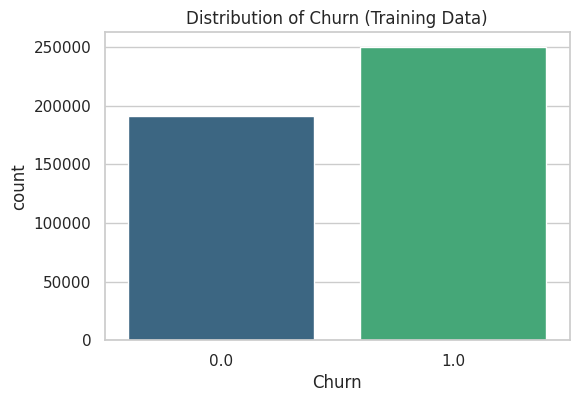

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# 1. Distribution of Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='Churn', palette='viridis')
plt.title('Distribution of Churn (Training Data)')
plt.show()

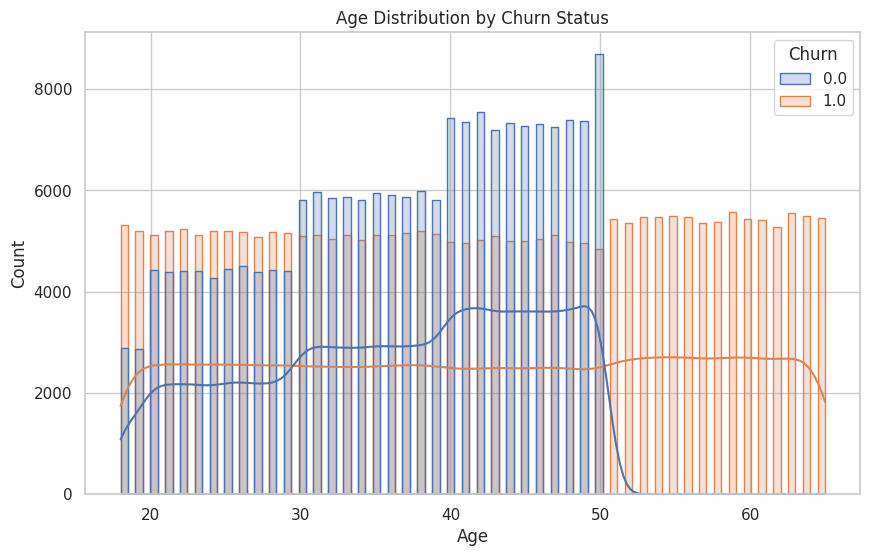

In [34]:
# 2. Age Distribution by Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df_train, x='Age', hue='Churn', kde=True, element='step')
plt.title('Age Distribution by Churn Status')
plt.show()

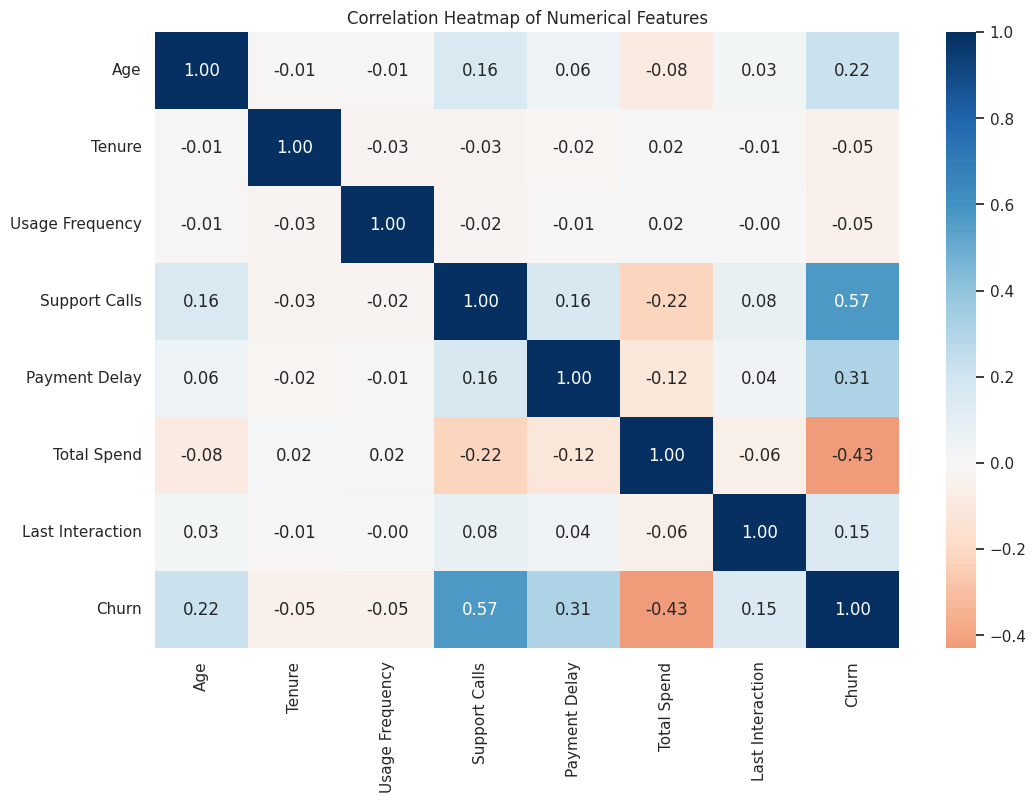

In [35]:
# 3. Correlation Heatmap (Numerical Features)
plt.figure(figsize=(12, 8))
numeric_df = df_train.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

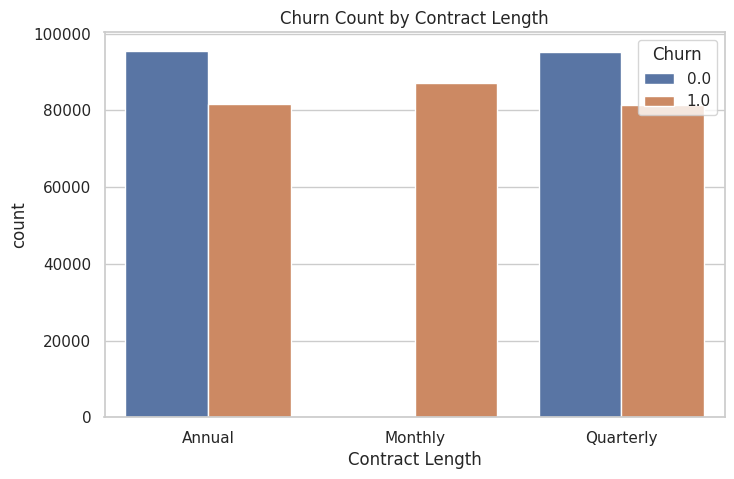

In [36]:
# 4. Contract Length vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Contract Length', hue='Churn')
plt.title('Churn Count by Contract Length')
plt.show()

In [30]:
# --- 3. Feature Selection and Preprocessing ---
X_train = df_train.drop('Churn', axis=1)
y_train = df_train['Churn']

X_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']

# Identify column types
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Define Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


In [31]:
# --- 4. Build and Train Model Pipeline ---
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Train on the training dataset
model_pipeline.fit(X_train, y_train)
print("Model training on training dataset complete.")

Model training on training dataset complete.


Test Accuracy: 0.5713

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.19      0.32     33881
           1       0.53      0.99      0.69     30493

    accuracy                           0.57     64374
   macro avg       0.74      0.59      0.50     64374
weighted avg       0.75      0.57      0.49     64374



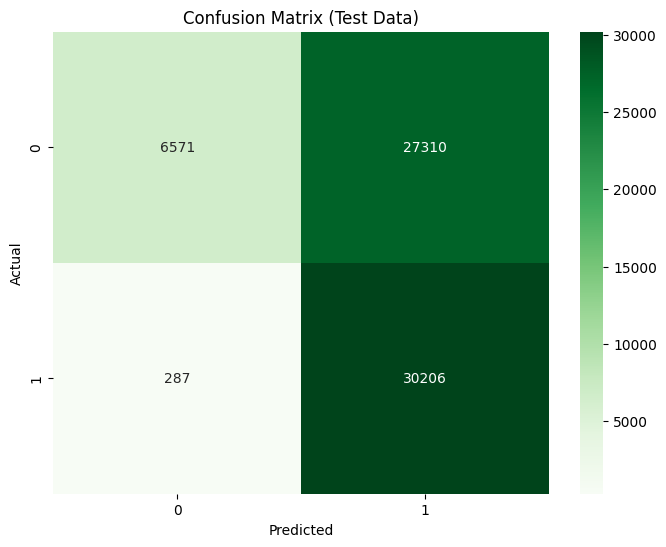

In [32]:
# --- 5. Prediction and Evaluation on Test Dataset ---
y_pred = model_pipeline.predict(X_test)

# Metrics
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()